## Raw Dataset

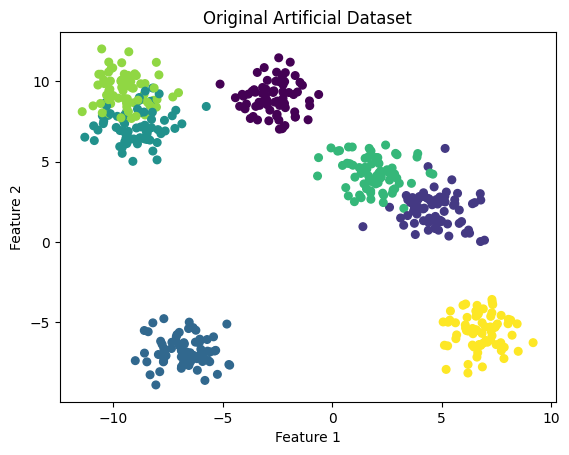

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, MiniBatchKMeans, SpectralClustering, DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
import random


# 生成人工数据集
def generate_artificial_datasets(n_samples=300, n_clusters=3, n_features=2, cluster_std=1.0, random_state=None):
    """
    生成用于测试聚类算法的人工数据集
    """
    X, y = make_blobs(n_samples=n_samples, centers=n_clusters, n_features=n_features,
                      cluster_std=cluster_std, random_state=random_state)
    return X, y

# 调用函数生成数据
X, y = generate_artificial_datasets(n_samples=500, n_clusters=7, n_features=2, cluster_std=1.0, random_state=42)

# 可视化数据
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='viridis')
plt.title("Original Artificial Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



## 基础KMeans

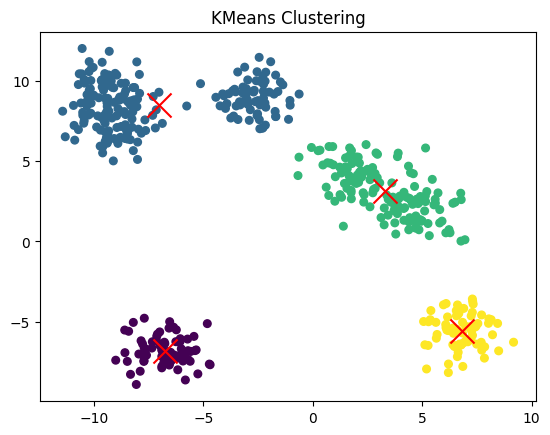

In [2]:
kmeans = KMeans(n_clusters=4, random_state=0)
y_kmeans = kmeans.fit_predict(X)

# 画出聚类结果
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.title("KMeans Clustering")
plt.show()


## 使用肘式法则找到最优的k，再执行KMeans

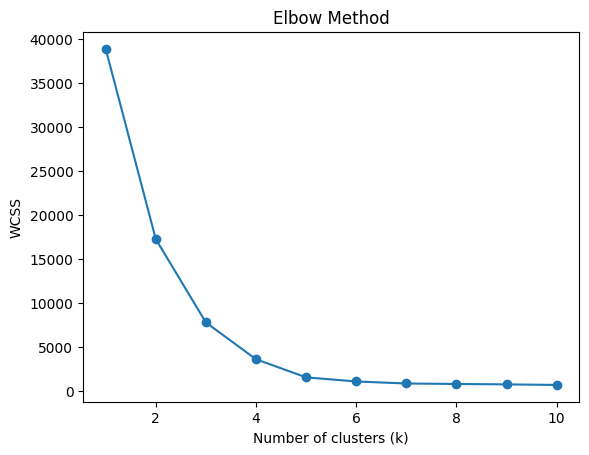

In [3]:
def elbow_method(X, max_k=10):
    """
    使用肘方法确定最佳的k值。

    参数：
    X : 输入数据，形状为 (n_samples, n_features)
    max_k : 最大的k值范围，默认为10
    """
    wcss = []  # 存储每个k值对应的簇内误差平方和（Within-Cluster Sum of Squares）
    for i in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=i, random_state=0)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)
    # 绘制肘方法图
    plt.plot(range(1, max_k + 1), wcss, marker='o')
    plt.title('Elbow Method')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('WCSS')
    plt.show()


elbow_method(X)

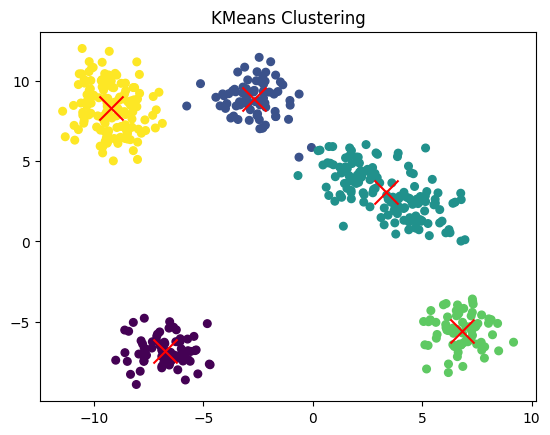

In [4]:
opt_k = 5
kmeans = KMeans(n_clusters=opt_k, random_state=0)
y_kmeans = kmeans.fit_predict(X)

# 画出聚类结果
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.title("KMeans Clustering")
plt.show()

## 1. **KMeans++**

- **改进点**：解决初始中心选择敏感问题。
- **方法**：在选择初始聚类中心时，使每个新中心尽量远离已选中心，从而避免 KMeans 因随机初始化带来的局部最优问题。
- **优势**：有效提高聚类结果的稳定性，通常在收敛速度和准确性方面优于传统 KMeans。

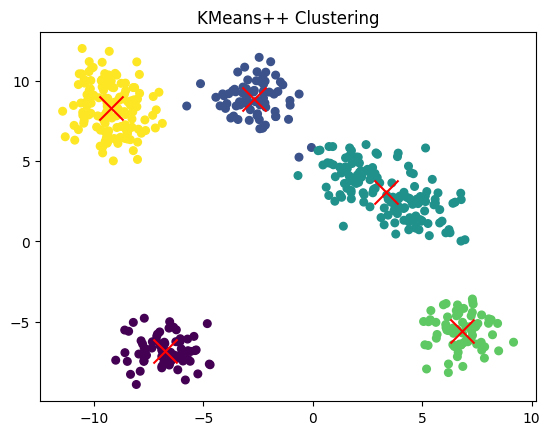

In [5]:
kmeans_pp = KMeans(n_clusters=5, init="k-means++", random_state=0)
y_kmeans_pp = kmeans_pp.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans_pp, s=30, cmap='viridis')
plt.scatter(kmeans_pp.cluster_centers_[:, 0], kmeans_pp.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.title("KMeans++ Clustering")
plt.show()


## 2. **Mini-Batch KMeans**

- **改进点**：适用于大规模数据。
- **方法**：每次随机选取小批量数据点进行更新，而不是使用全量数据，逐步优化聚类中心。
- **优势**：大大减少了计算量，适合处理大数据集，速度更快，但可能会牺牲一些聚类精度。

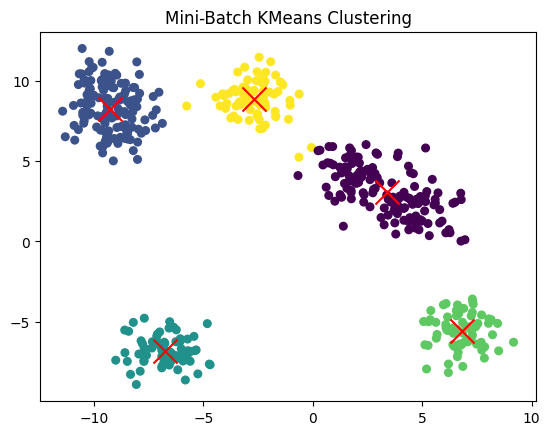

In [6]:
mini_batch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=0)
y_mini_batch_kmeans = mini_batch_kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_mini_batch_kmeans, s=30, cmap='viridis')
plt.scatter(mini_batch_kmeans.cluster_centers_[:, 0], mini_batch_kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.title("Mini-Batch KMeans Clustering")
plt.show()


## 3. **应用二分 KMeans**

二分 K-Means 是一种基于 K-Means 的改进算法，它采用了一种自顶向下的分裂聚类策略（选择能最大程度降低误差平方和（SSE）的簇进行分裂）。其核心思想是通过不断地将现有的簇进行二等分，逐步构建最终所需的聚类结果。


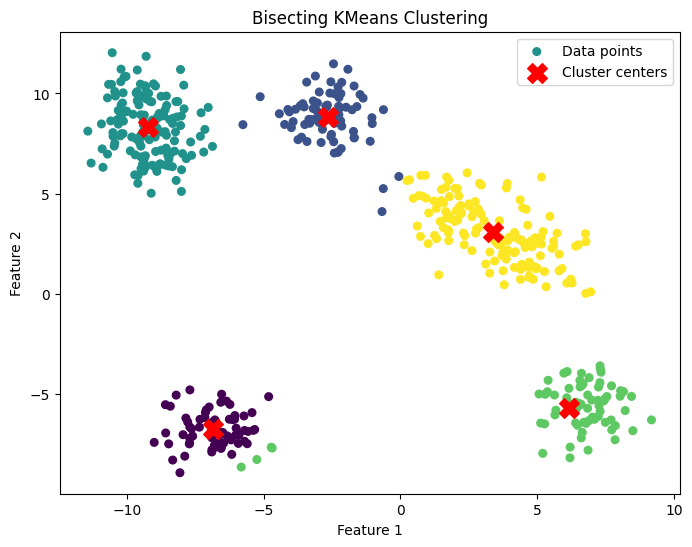

In [7]:
# 使用 Bisecting KMeans 进行聚类
from sklearn.cluster import BisectingKMeans

bisect_means = BisectingKMeans(n_clusters=5, random_state=0).fit(X)
labels = bisect_means.labels_
centers = bisect_means.cluster_centers_

# 绘制聚类结果
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, marker='o', label="Data points")
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red', marker='X', label="Cluster centers")
plt.title("Bisecting KMeans Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

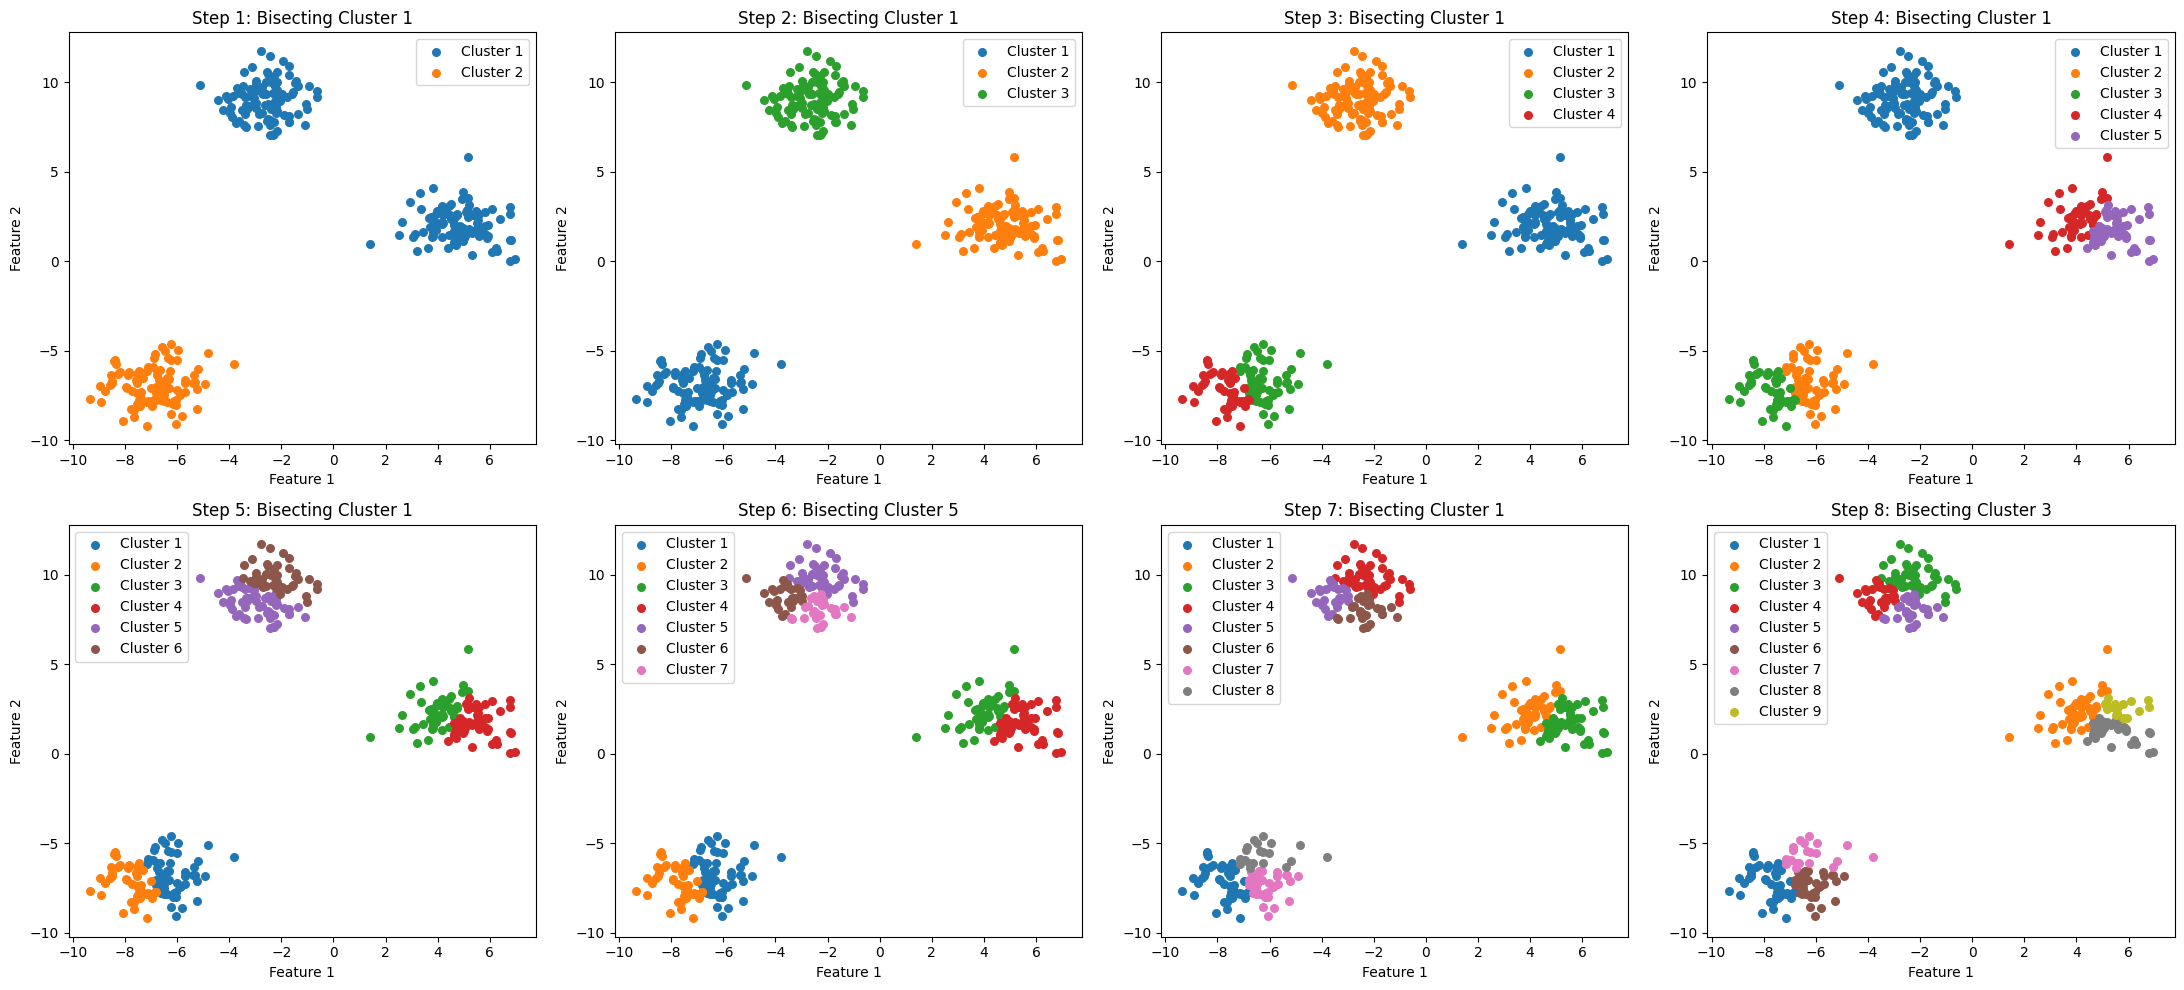

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

def generate_artificial_datasets(n_samples=300, n_clusters=3, n_features=2, cluster_std=1.0, random_state=None):
    """
    生成用于测试聚类算法的人工数据集
    """
    X, y = make_blobs(n_samples=n_samples, centers=n_clusters, n_features=n_features,
                      cluster_std=cluster_std, random_state=random_state)
    return X, y

# 调用函数生成数据
X, y = generate_artificial_datasets(n_samples=300, n_clusters=3, n_features=2, cluster_std=1.0, random_state=42)

def bisecting_kmeans_visualization(X, n_clusters=3, random_state=0):
    clusters = [X]
    labels = np.zeros(X.shape[0], dtype=int)
    current_cluster_label = 0
    n_steps = 0

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.ravel()

    while len(clusters) < n_clusters:
        # 选择最大簇进行二分
        max_cluster_idx = np.argmax([len(cluster) for cluster in clusters])
        to_split = clusters.pop(max_cluster_idx)

        # 对选中的簇进行KMeans二分
        kmeans = KMeans(n_clusters=2, random_state=random_state).fit(to_split)
        split_labels = kmeans.labels_

        # 新生成的两个簇
        cluster1 = to_split[split_labels == 0]
        cluster2 = to_split[split_labels == 1]

        # 更新标签
        labels[np.isin(X, cluster1).all(axis=1)] = current_cluster_label
        labels[np.isin(X, cluster2).all(axis=1)] = current_cluster_label + 1
        current_cluster_label += 2

        # 保存新的簇
        clusters.append(cluster1)
        clusters.append(cluster2)

        # 可视化当前步骤的聚类结果
        ax = axes[n_steps]
        for i, cluster in enumerate(clusters):
            ax.scatter(cluster[:, 0], cluster[:, 1], s=30, label=f"Cluster {i+1}")
        ax.set_title(f"Step {n_steps + 1}: Bisecting Cluster {max_cluster_idx + 1}")
        ax.legend()
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

        n_steps += 1
        if n_steps >= len(axes):  # 限制可视化的步数
            break

    plt.tight_layout()
    plt.show()

# 运行并可视化 Bisecting KMeans 聚类过程
bisecting_kmeans_visualization(X, n_clusters=10)


Automatically created module for IPython interactive environment


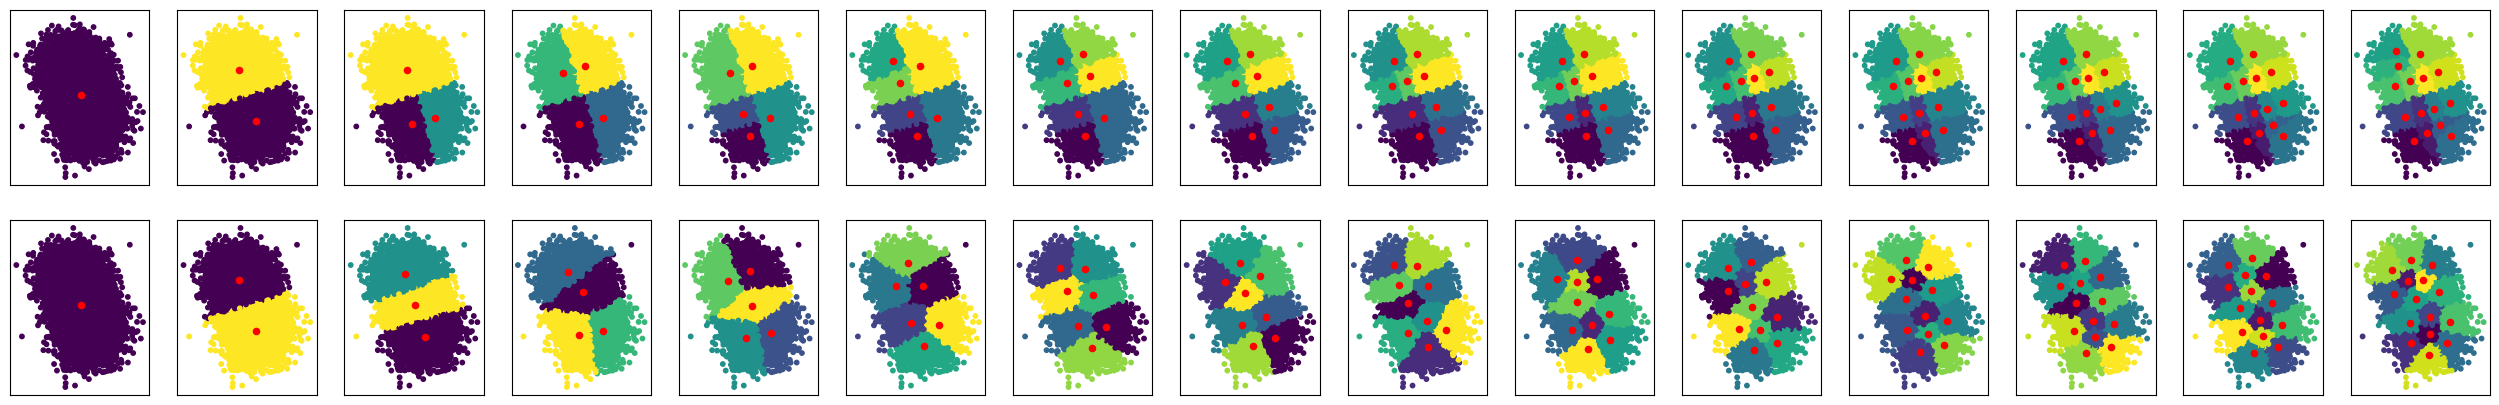

In [9]:
import matplotlib.pyplot as plt

from sklearn.cluster import BisectingKMeans, KMeans
from sklearn.datasets import make_blobs

print(__doc__)


# Generate sample data
n_samples = 10000
random_state = 0

X, _ = make_blobs(n_samples=n_samples, centers=2, random_state=random_state)

# Number of cluster centers for KMeans and BisectingKMeans
n_clusters_list = [x for x in range(1,16)]

# Algorithms to compare
clustering_algorithms = {
    "Bisecting K-Means": BisectingKMeans,
    "K-Means": KMeans,
}

# Make subplots for each variant
fig, axs = plt.subplots(
    len(clustering_algorithms), len(n_clusters_list), figsize=(32, 5)
)

axs = axs.T

for i, (algorithm_name, Algorithm) in enumerate(clustering_algorithms.items()):
    for j, n_clusters in enumerate(n_clusters_list):
        algo = Algorithm(n_clusters=n_clusters, random_state=random_state, n_init=3)
        algo.fit(X)
        centers = algo.cluster_centers_

        axs[j, i].scatter(X[:, 0], X[:, 1], s=10, c=algo.labels_)
        axs[j, i].scatter(centers[:, 0], centers[:, 1], c="r", s=20)

        # axs[j, i].set_title(f"{algorithm_name} : {n_clusters} clusters")


# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

## 4. **Fuzzy C-Means (FCM)**

- **改进点**：允许数据点属于多个簇。

FCM 算法允许数据点属于多个簇，而不是像传统的硬聚类算法（如 K-Means）那样只属于一个簇。每个数据点对各个簇都有一个隶属度，这个隶属度表示该数据点属于该簇的程度，取值范围在 0 到 1 之间，且一个数据点对所有簇的隶属度之和为 1。


根据数据点对簇的隶属度来计算簇中心。

隶属度高的数据点（即更倾向于属于该簇的数据点）对簇中心的贡献更大，隶属度低的数据点对簇中心的贡献相对较小。

In [10]:
!pip install scikit-fuzzy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# 调用函数生成数据
X, y = generate_artificial_datasets(n_samples=600, n_clusters=7, n_features=2, cluster_std=1.0, random_state=42)


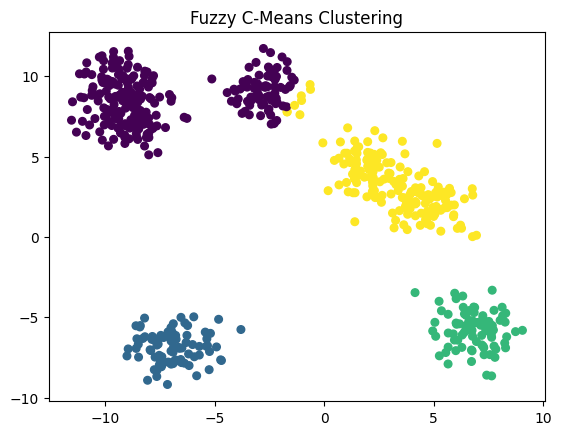

In [12]:
import skfuzzy as fuzz

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X.T, 4, 2, error=0.005, maxiter=1000)
y_fcm = np.argmax(u, axis=0)

plt.scatter(X[:, 0], X[:, 1], c=y_fcm, s=30, cmap='viridis')
plt.title("Fuzzy C-Means Clustering")
plt.show()


**`fuzz.cluster.cmeans`**：这是`scikit-fuzzy`库中的模糊C均值聚类算法。它接受数据和一系列参数来进行聚类，返回簇中心和隶属度矩阵等结果。

**`X.T`**：表示将数据 `X` 转置。在模糊C均值中，算法要求数据的每一行是一个特征，每一列是一个样本。假设 `X` 的形状是 (样本数, 特征数)，则 `X.T` 可以将数据调整为所需的形状 (特征数, 样本数)。

**`4`**：指定了聚类的数量，即将数据划分为4个簇。

**`2`**：模糊系数 (fuzziness parameter)，通常记为 `m`，用于控制隶属度的模糊程度。`m` 通常大于1，且通常取值在 [1.5, 2.5] 之间。`m=2` 表示每个点可以在2个簇之间有较为显著的隶属度。

**`error=0.005`**：误差阈值，用于判断聚类是否收敛。当两个迭代间的簇中心的变化小于该阈值时，算法认为已经收敛，停止迭代。

**`maxiter=1000`**：最大迭代次数。设置聚类的最多迭代次数，如果在达到 `maxiter` 次迭代之前达到 `error` 的收敛条件，算法将提前结束。

---


**`cntr`**：返回的簇中心的坐标，每个中心对应一个簇。`cntr` 的形状是 `(4, 特征数)`，其中4是簇的数量，特征数是每个数据点的维度。

**`u`**：隶属度矩阵，形状为 `(4, 样本数)`，表示每个数据点对每个簇的隶属度。`u[i, j]` 表示第 `j` 个数据点属于第 `i` 个簇的隶属度。隶属度矩阵的列和为1，因为每个数据点的隶属度在所有簇之间的总和为1。

使用模糊C均值（Fuzzy C-Means, FCM）算法对数据进行聚类。模糊C均值是一种软聚类方法，它允许数据点属于多个簇，并通过隶属度（membership）来表示数据点与各个簇之间的关联度。

## 5. **KMedoids (PAM)**

- **改进点**：减少对异常值的敏感性。
- **方法**：聚类中心选择簇中最具代表性的样本（即 medoid）而不是平均值，类似于“中位数”的概念。
- **优势**：对异常值更鲁棒，适合处理离群值较多的数据集，但计算开销相对较大。

K-Medoids 算法的核心思想是找到代表性的数据点（medoids），使得簇内样本到其中心的距离和最小。具体步骤如下：

1. **初始化**：从数据集中随机选择 `k` 个数据点作为初始的 medoids（中心点）。
2. **分配数据点**：将每个数据点分配给距离最近的 medoid，以形成 `k` 个初始簇。
3. **选择最佳 medoid**：
   - 对于每一个簇中的数据点，计算将当前的 medoid 替换为簇中另一个点后，簇内所有数据点到新中心的距离之和。
   - 如果某个点作为新的 medoid 后可以降低簇内点到中心的距离和，就更新为新的 medoid。
   - 这一过程对每个簇重复，直到找出每个簇的最佳 medoid，使得簇内距离和最小。
4. **迭代**：
   - 重新分配每个数据点到最近的 medoid，形成新的簇。
   - 不断重复步骤 3 和 4，直到簇分配不再发生变化（收敛）或达到指定的迭代次数。

### K-Medoids 和 K-Means 的区别

- **中心点**：
  - K-Means 的中心点（质心）是簇中数据点的平均值，这可能会受离群点影响。
  - K-Medoids 选择的是数据集中的实际点，因此更能抵抗噪声和离群点的干扰。
- **适用性**：
  - K-Means 主要用于欧氏距离度量的情况。
  - K-Medoids 可以使用任意距离度量（例如曼哈顿距离、汉明距离等），更灵活。

In [13]:
!pip install scikit-learn-extra

  Using cached scikit-learn-extra-0.3.0.tar.gz (818 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build scikit-learn-extra


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [77 lines of output]
  C:\Users\20206\AppData\Local\Temp\pip-build-env-8_27i766\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
  !!
  
          ********************************************************************************
          Usage of dash-separated 'description-file' will not be supported in future
          versions. Please use the underscore name 'description_file' instead.
          (Affected: scikit-learn-extra).
  
          Available configuration options are listed in:
          https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
  
          This deprecation is overdue, please update your project and remove deprecated
          calls to avoid build errors in the future.
  
          See https://github.com/pypa/setuptools/discu

In [14]:
try:
    from sklearn_extra.cluster import KMedoids
    kmedoids = KMedoids(n_clusters=4, random_state=0)
    y_kmedoids = kmedoids.fit_predict(X)
    plt.scatter(X[:, 0], X[:, 1], c=y_kmedoids, s=30, cmap='viridis')
    plt.scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1], s=300, c='red', marker='x')
    plt.title('KMedoids Clustering')
    plt.show()
except Exception as e:
    print(f'Skip KMedoids cell: {e}')


Skip KMedoids cell: No module named 'sklearn_extra'


## 6. **DBSCAN-KMeans 混合**

- **改进点**：结合密度聚类与 KMeans。
- **方法**：使用 DBSCAN 识别密集数据点（核心样本）和离群点，再用 KMeans 进一步对核心样本聚类。
- **优势**：能够更好地处理含噪声的数据集，同时提升分离性，对非球形数据表现良好。

### DBSCAN 的基本原理

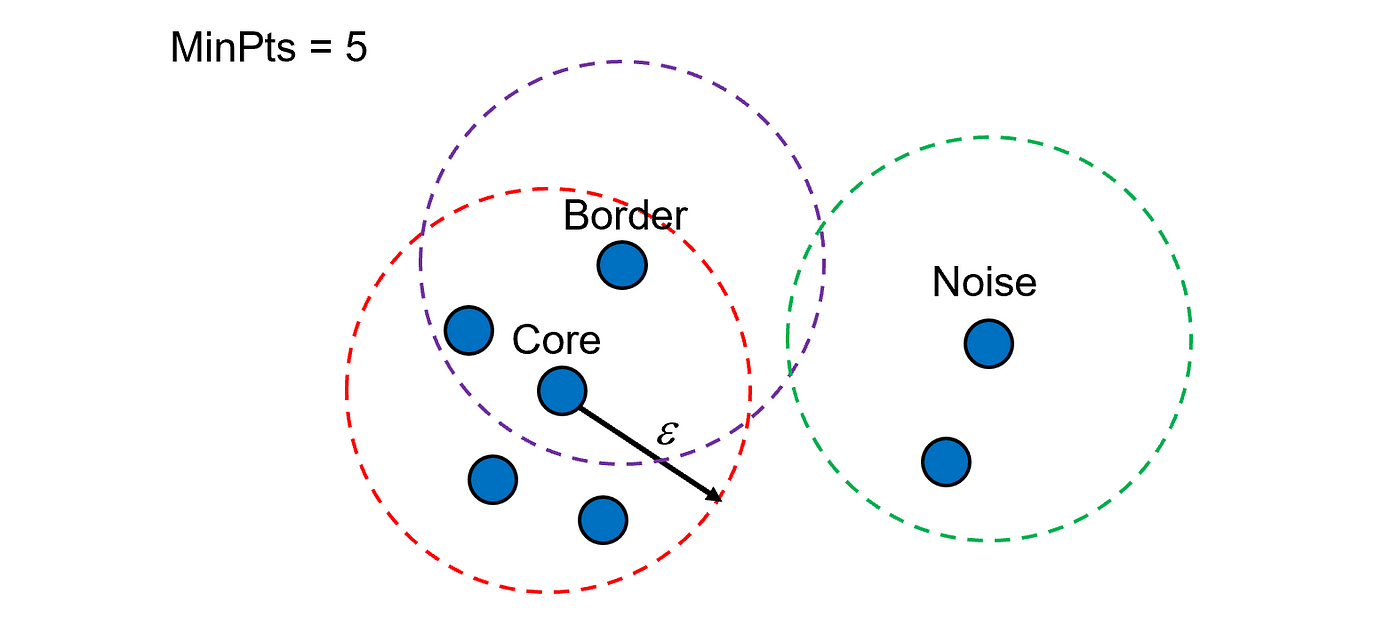

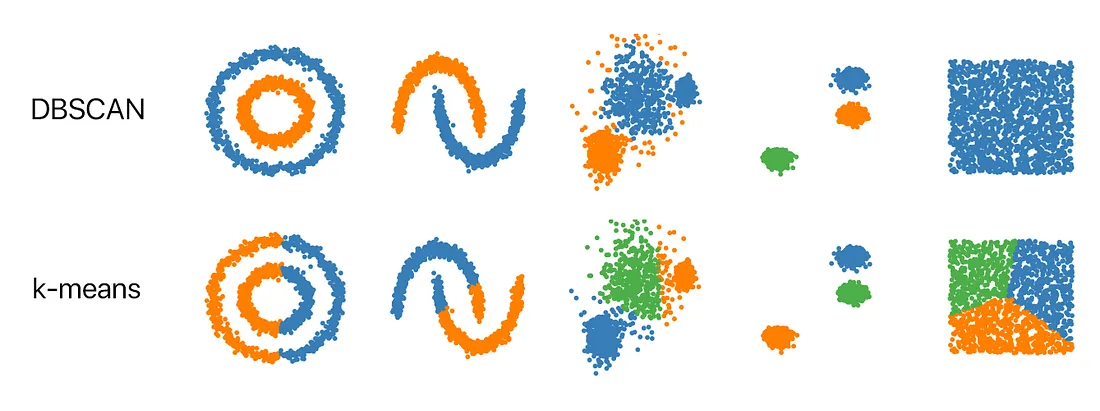

DBSCAN 的核心思想是通过密度连接（density connectivity）来发现高密度区域，并将这些区域作为簇。算法的基本概念包括以下几个定义：

1. **核心点（Core Point）**：如果一个数据点在指定的半径 `ε` 内包含至少 `minPts` 个其他数据点，那么该点被称为核心点。
2. **边界点（Border Point）**：如果一个数据点本身不满足核心点的条件，但它位于某个核心点的 `ε` 邻域内，则称该点为边界点。
3. **噪声点（Noise Point）**：既不是核心点，也不是边界点的数据点称为噪声点，即离群点。

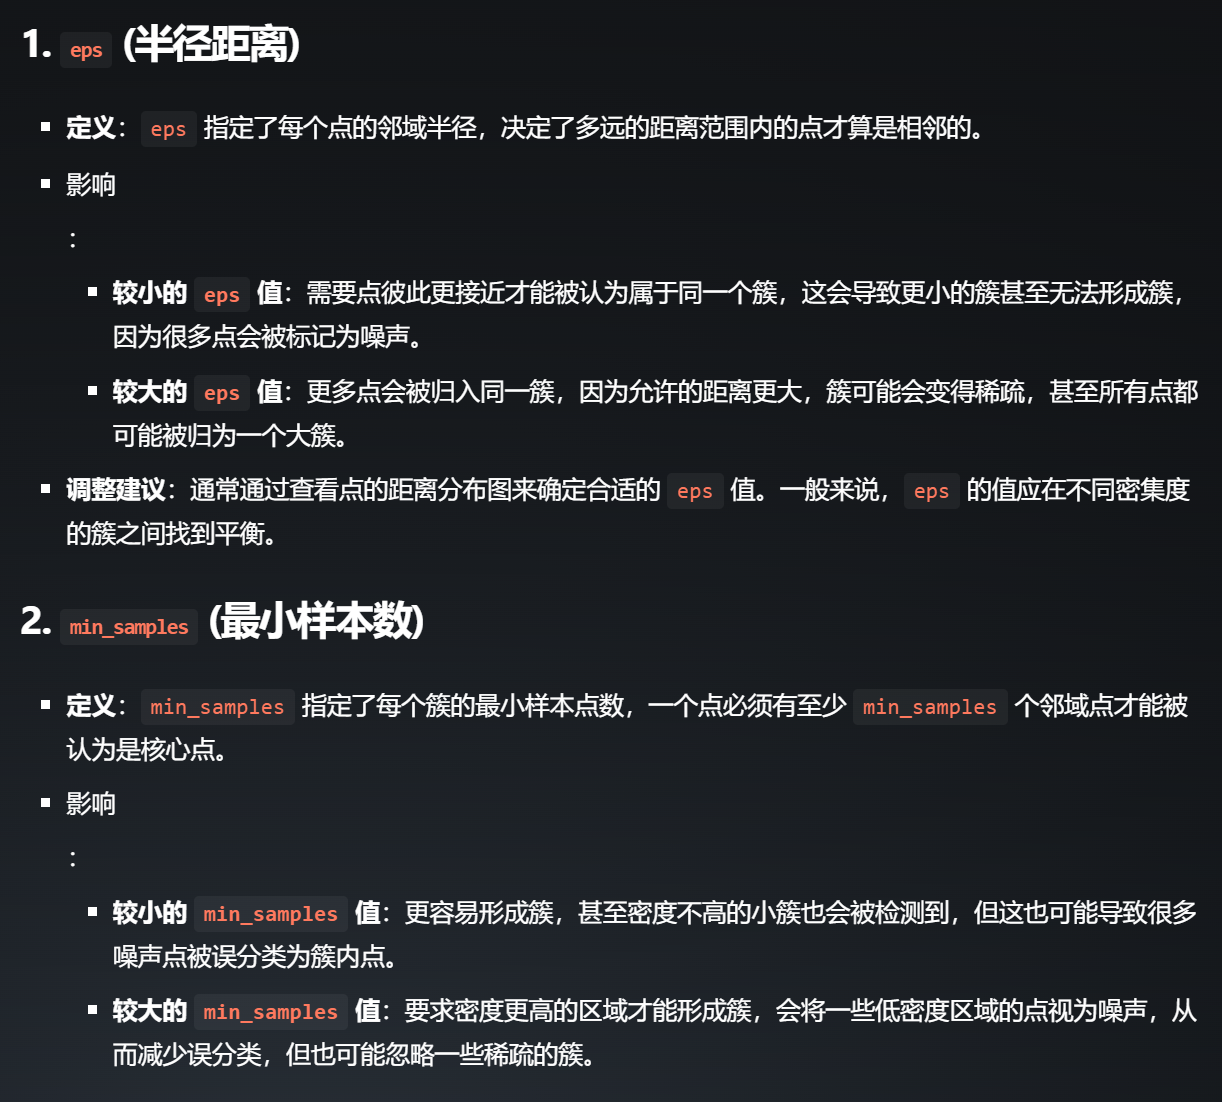

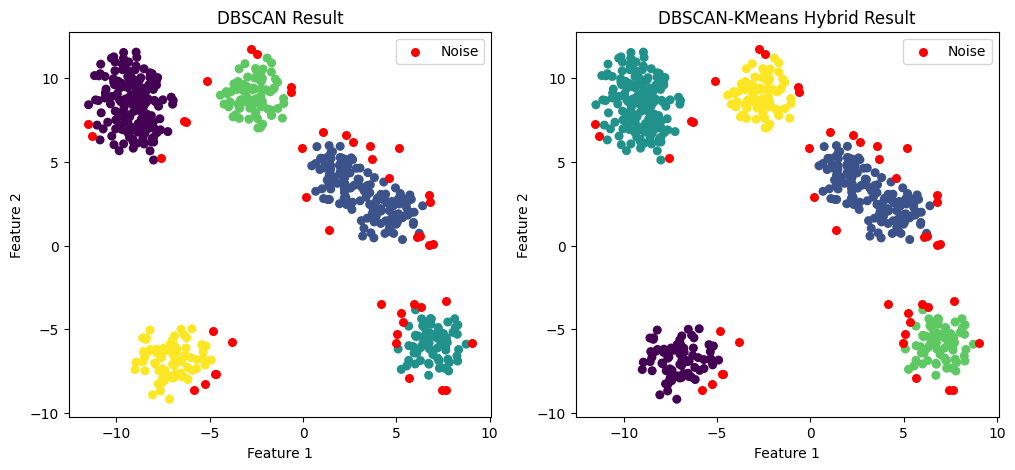

In [15]:
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# 生成人工数据集
def generate_artificial_datasets(n_samples=300, n_clusters=3, n_features=2, cluster_std=1.0, random_state=None):
    """
    生成用于测试聚类算法的人工数据集
    """
    X, y = make_blobs(n_samples=n_samples, centers=n_clusters, n_features=n_features,
                      cluster_std=cluster_std, random_state=random_state)
    return X, y

# 调用函数生成数据
X, y = generate_artificial_datasets(n_samples=600, n_clusters=7, n_features=2, cluster_std=1.0, random_state=42)

# 设置 DBSCAN 参数
dbscan = DBSCAN(eps=0.7, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# 提取 DBSCAN 检测到的非噪声点
non_noise_points = X[dbscan_labels != -1]
non_noise_labels = dbscan_labels[dbscan_labels != -1]

# 使用 KMeans 对非噪声点进行进一步聚类
kmeans = KMeans(n_clusters=len(set(non_noise_labels)), random_state=0)
kmeans_labels = kmeans.fit_predict(non_noise_points)

# 组合 DBSCAN 和 KMeans 的聚类结果
combined_labels = np.full(dbscan_labels.shape, -1)  # 初始化为噪声
combined_labels[dbscan_labels != -1] = kmeans_labels  # 将非噪声点的聚类结果合并

# 可视化 DBSCAN 结果，噪声点标为红色
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# 非噪声点
plt.scatter(X[dbscan_labels != -1][:, 0], X[dbscan_labels != -1][:, 1],
            c=dbscan_labels[dbscan_labels != -1], cmap='viridis', s=30)
# 噪声点
plt.scatter(X[dbscan_labels == -1][:, 0], X[dbscan_labels == -1][:, 1],
            color='red', s=30, label="Noise")
plt.title("DBSCAN Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

# 可视化 DBSCAN-KMeans 混合结果，噪声点标为红色
plt.subplot(1, 2, 2)
# 非噪声点
plt.scatter(X[combined_labels != -1][:, 0], X[combined_labels != -1][:, 1],
            c=combined_labels[combined_labels != -1], cmap='viridis', s=30)
# 噪声点
plt.scatter(X[combined_labels == -1][:, 0], X[combined_labels == -1][:, 1],
            color='red', s=30, label="Noise")
plt.title("DBSCAN-KMeans Hybrid Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()


## 7. **Kernel KMeans**

- **改进点**：解决线性不可分的数据。
- **方法**：通过核方法将数据映射到高维空间，再进行 KMeans 聚类。
- **优势**：适合非线性可分数据，但计算复杂度较高。

In [16]:
!pip install python-kkmeans


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


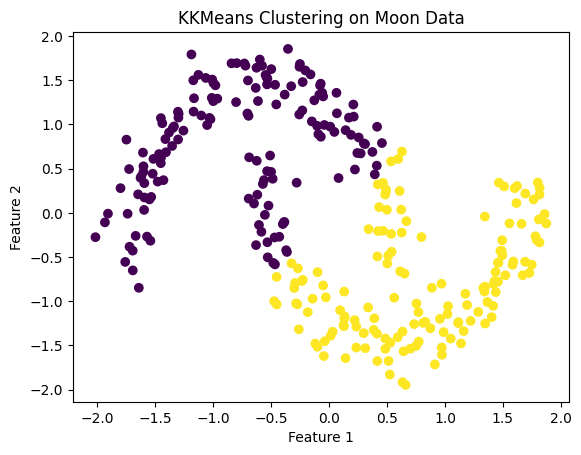

In [17]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_blobs
from kkmeans import rbf_kernel, kkmeans, kmeans_plusplus

n_clusters = 2  # 对于月亮数据，通常选择2个聚类
X, _ = make_moons(n_samples=300, noise=0.1)  # 添加一些噪声以增加复杂性
X_scaled = StandardScaler().fit_transform(X)

cluster_assignments = kkmeans(X, n_clusters, kernel_function=lambda X: rbf_kernel(X, sigma=0.4),
        initial_cluster_assignments=kmeans_plusplus, max_iterations=10, tol=1e-2)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_assignments)
plt.title('KKMeans Clustering on Moon Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

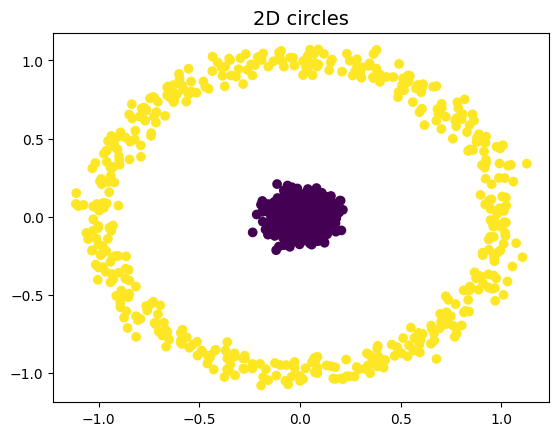

In [18]:
from sklearn.datasets import make_circles
from kkmeans import rbf_kernel, kkmeans, kmeans_plusplus

n_clusters = 2
X, _ = make_circles(n_samples=1000, factor=0.1, noise=0.05, random_state=0)

cluster_assignments = kkmeans(X, n_clusters, kernel_function=lambda X: rbf_kernel(X, sigma=0.4),
        initial_cluster_assignments=kmeans_plusplus, max_iterations=10, tol=1e-2)

plt.scatter(X[:, 0], X[:, 1], c=cluster_assignments, cmap='viridis', marker='o')
plt.title('2D circles', fontsize=14)
plt.show()

## 模型对比

### circle

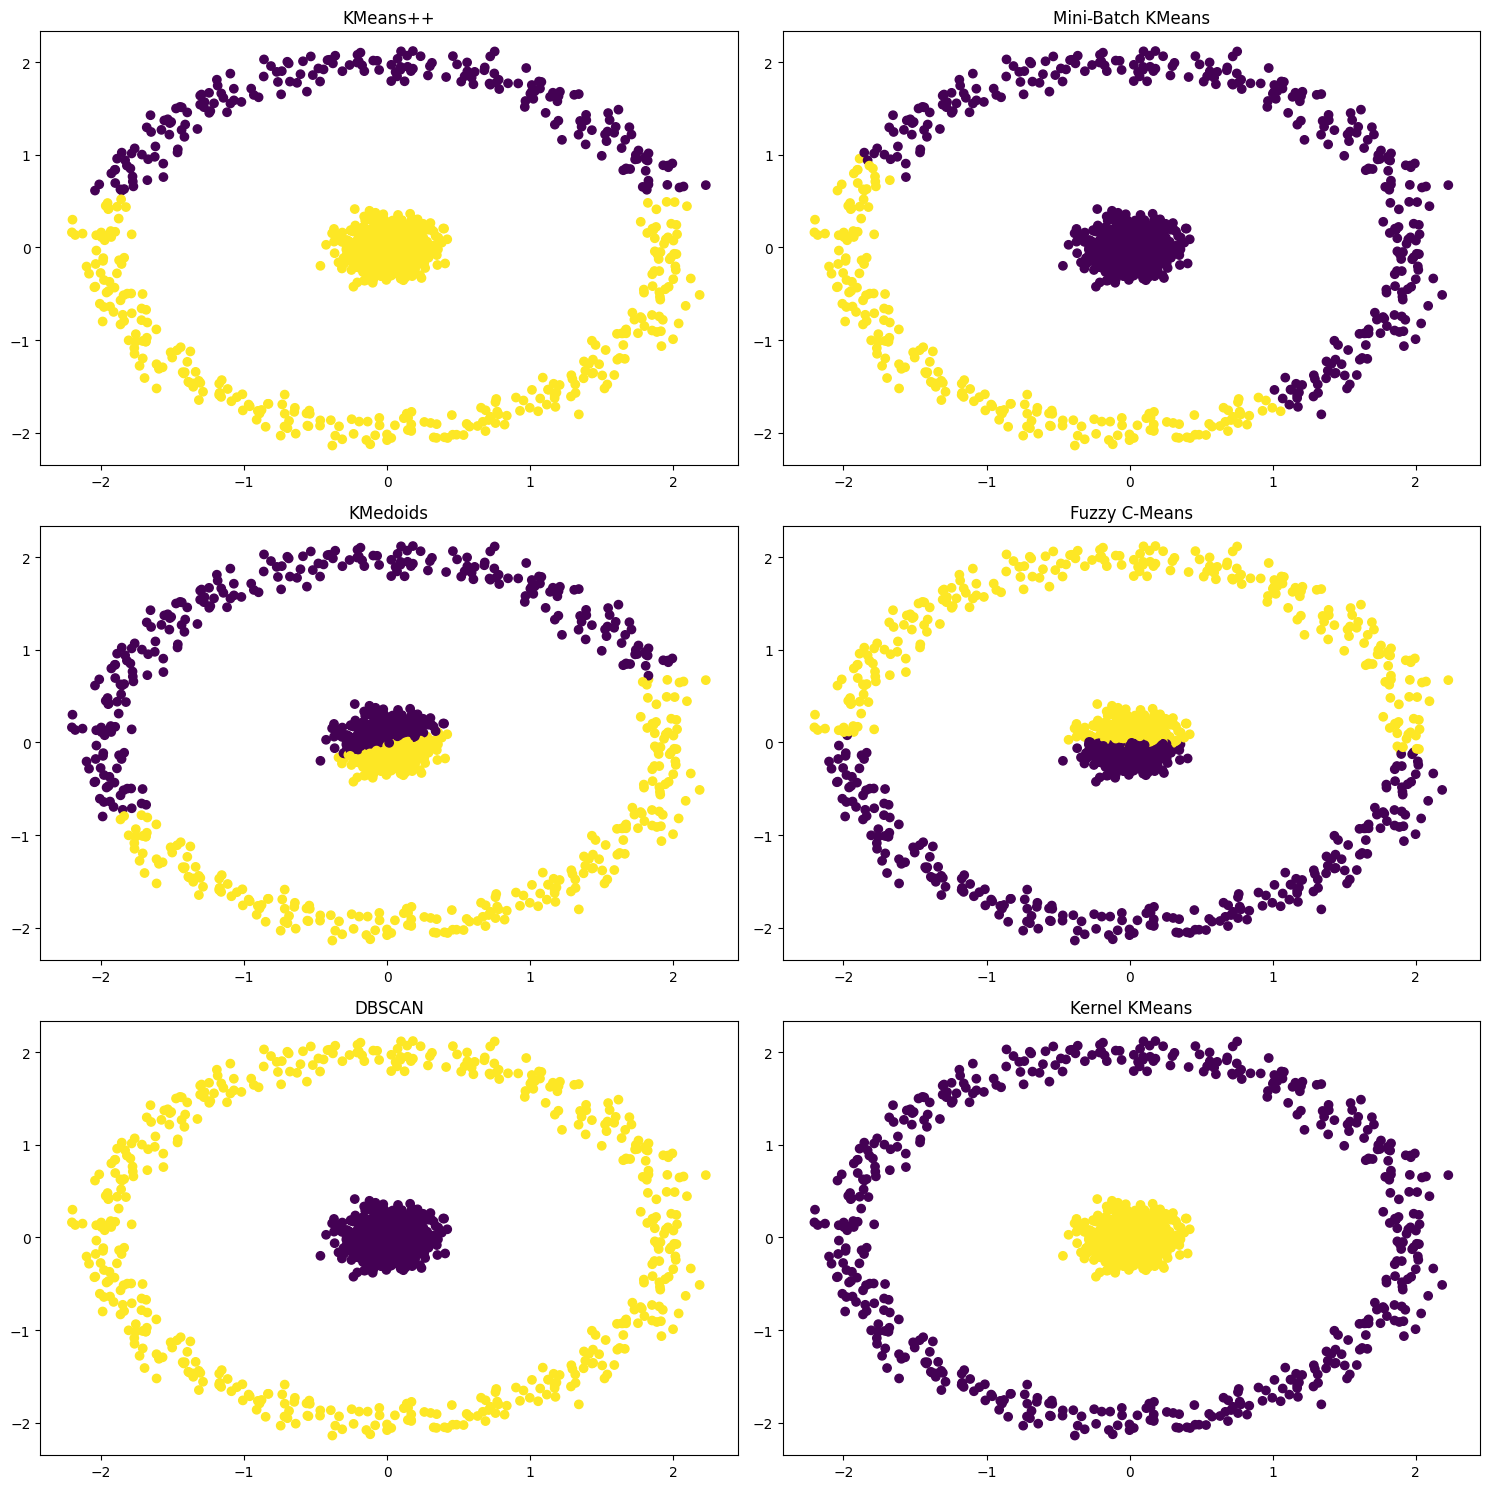

### moon

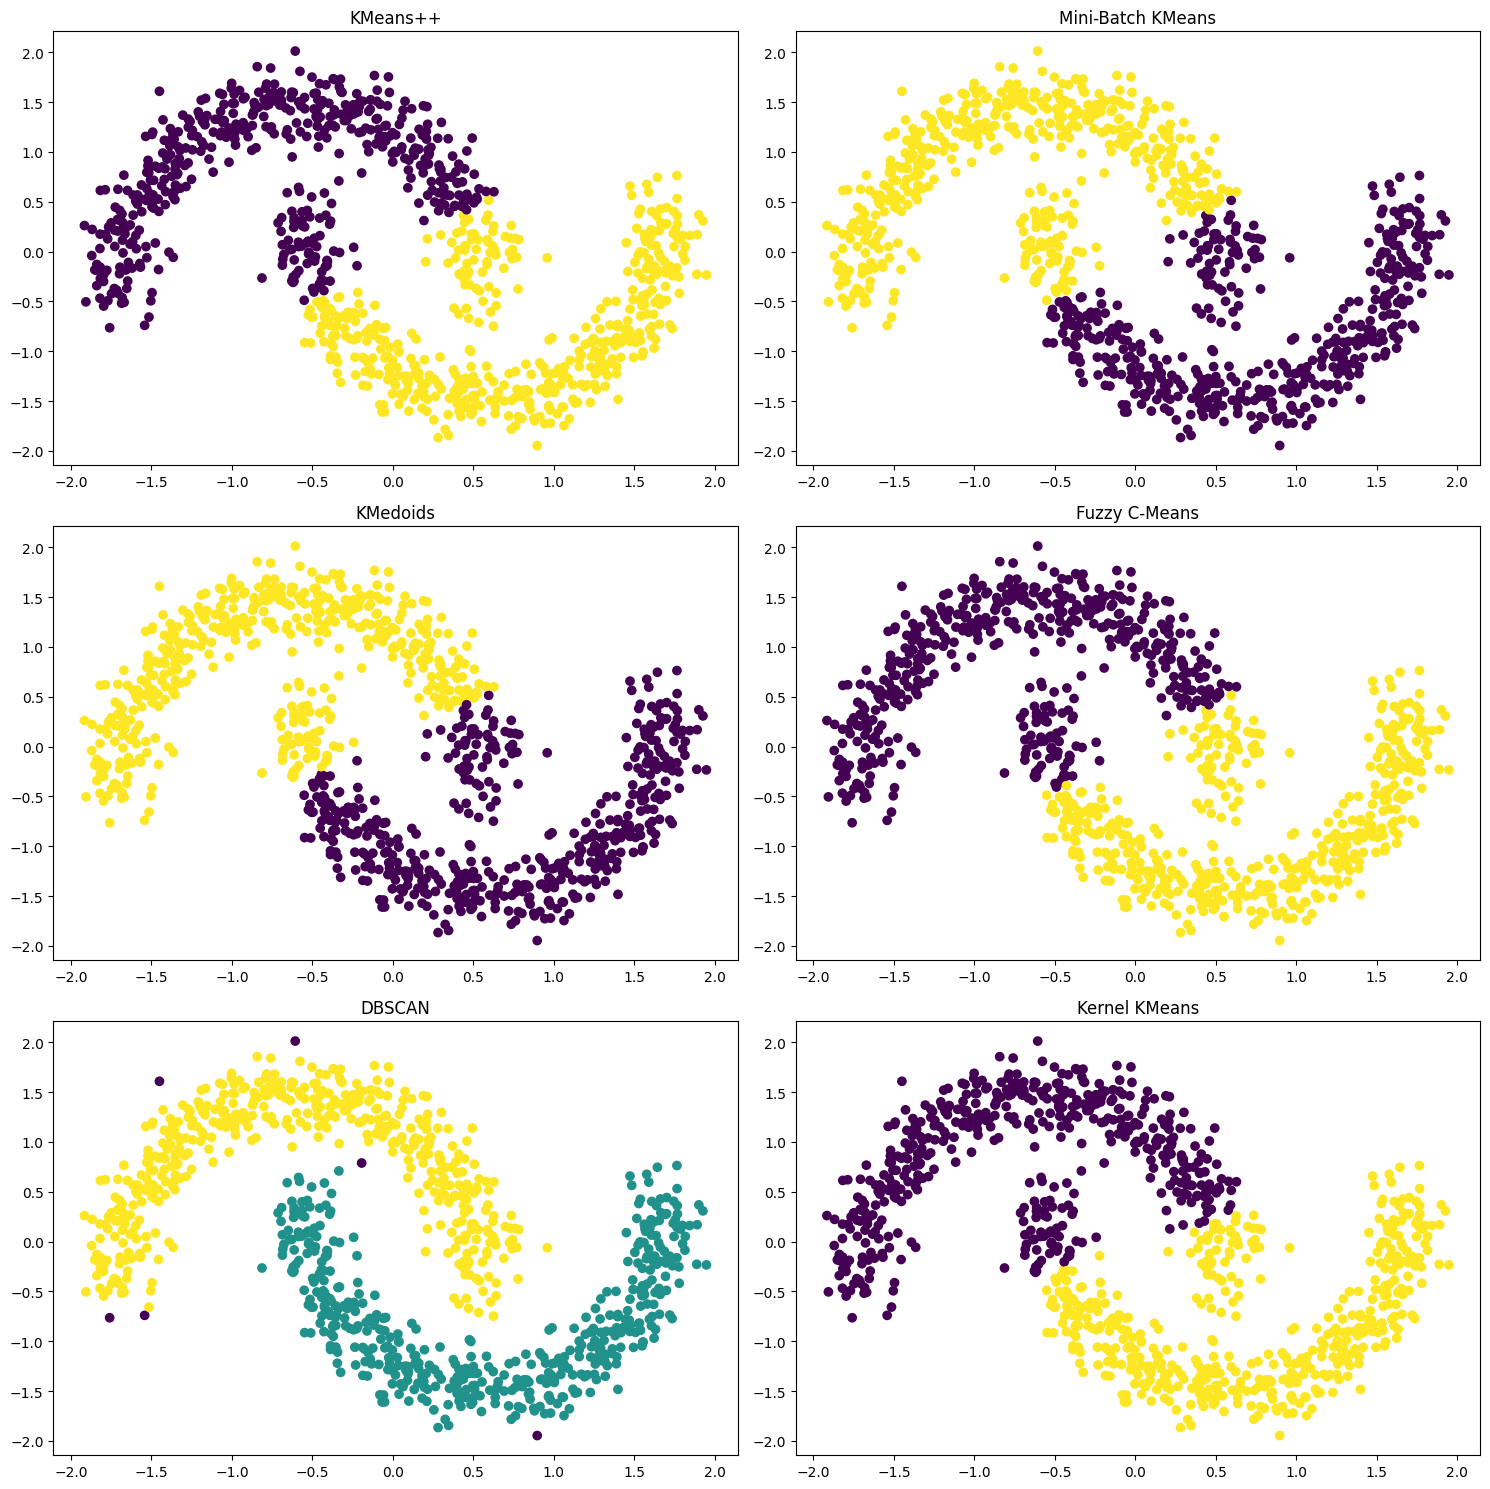

## 效果比较

In [19]:
try:
    from sklearn_extra.cluster import KMedoids
    kmedoids = KMedoids(n_clusters=4, random_state=0)
    y_kmedoids = kmedoids.fit_predict(X)
    plt.scatter(X[:, 0], X[:, 1], c=y_kmedoids, s=30, cmap='viridis')
    plt.scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1], s=300, c='red', marker='x')
    plt.title('KMedoids Clustering')
    plt.show()
except Exception as e:
    print(f'Skip KMedoids cell: {e}')


Skip KMedoids cell: No module named 'sklearn_extra'
